In [1]:
# PACKAGES
## data manipulation
import pandas as pd
import numpy as np

## confidence interval
import math

# ANOVA
import scipy.stats as stats

## data viz
import seaborn as sns
import matplotlib.pyplot as plt

## linear and polynominal regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures

## cluster analysis
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# PATHS AND METHODS

## My min max scaler
def my_scaler(x_unscaled, x_min=None, x_max=None):
    if x_min == None:
        x_min=x_unscaled.min()
    if x_max == None:
        x_max=x_unscaled.max()
    x_scaled = (x_unscaled - x_min)/(x_max - x_min)
    return x_scaled

## confidence interval 95%
def my_ci_95(stats, r=2):
    
    ci95_hi = []
    ci95_lo = []
    alpha = []

    for i in stats.index:
        m, c, s = stats.loc[i]
        a = 1.96*s/math.sqrt(c)
        ci95_hi.append(m + a)
        ci95_lo.append(m - a)
        alpha.append(a)

    stats['ci95_lo'] = ci95_lo
    stats['ci95_hi'] = ci95_hi
    stats['alpha'] = alpha

    stats['mean'] = round(stats['mean'], r)
    stats['alpha'] = round(stats['alpha'], r)

    return(stats.reset_index())

In [3]:
# DEFINING EXPERIMENT PARAMETERS
## seed list
seed_list = [428956419, 1954324947, 1145661099, 1835732737, 794161987, 1329531353, 200496737, 633816299, 1410143363, 1282538739]

## scenarion list
scenario_list = ['2ec_low_on', '2ec_low_off', '2ec_high_on', '2ec_high_off']
#scenario_list = ['2ec_high_off']

## algorithms list
#algo_list = ['tetris', 'thea', 'argos', 'faticanti']
algo_list = ['tetris', 'thea']

In [4]:
# IMPORT DATASETS

# dataframes
total_seed_server = pd.DataFrame()
total_seed_user = pd.DataFrame()
total_seed_service = pd.DataFrame()
# object to count the quantity of experiments
n_exp = 0

# loop to get results
for algo_name in algo_list:

    for scenario in scenario_list:

        ## count experiment
        n_exp = n_exp + 1

        for seed_value in seed_list:

            # server
            ## getting results by seeds
            each_seed_server = pd.read_csv(f"results/{algo_name}_logsserver_{scenario}_{seed_value}.csv")
            each_seed_server['seed'] = seed_value
            each_seed_server['scenario'] = scenario
            each_seed_server['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_server = pd.concat([total_seed_server, each_seed_server])
            total_seed_server = total_seed_server.reset_index(drop=True)

            # user
            ## getting results by seeds
            each_seed_user = pd.read_csv(f"results/{algo_name}_logsuser_{scenario}_{seed_value}.csv")
            each_seed_user['seed'] = seed_value
            each_seed_user['scenario'] = scenario
            each_seed_user['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_user = pd.concat([total_seed_user, each_seed_user])
            total_seed_user = total_seed_user.reset_index(drop=True)

            # service
            ## getting results by seeds
            each_seed_service = pd.read_csv(f"results/{algo_name}_logsservice_{scenario}_{seed_value}.csv")
            each_seed_service['seed'] = seed_value
            each_seed_service['scenario'] = scenario
            each_seed_service['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_service = pd.concat([total_seed_service, each_seed_service])
            total_seed_service = total_seed_service.reset_index(drop=True)

In [5]:
# FEATURE ENGINEERING

## create new obj to do feature engineering
dt_power = total_seed_server.loc[(total_seed_server['Available'])].reset_index(drop=True).copy()
dt_server = total_seed_server.loc[(total_seed_server['Available']) & (total_seed_server['CPU Demand'] > 0)].reset_index(drop=True).copy()
dt_user = total_seed_user.copy()
dt_service = total_seed_service.copy()

## alogrithm + scenario column
dt_power['algorithm_scenario'] = dt_power['algorithm'] + '_' + dt_server['scenario']
dt_server['algorithm_scenario'] = dt_server['algorithm'] + '_' + dt_server['scenario']
dt_user['algorithm_scenario'] = dt_user['algorithm'] + '_' + dt_user['scenario']
dt_service['algorithm_scenario'] = dt_service['algorithm'] + '_' + dt_service['scenario']

## Infra
dt_power['cloud'] = dt_power['scenario'].str.split('_', expand=True)[2]
dt_server['cloud'] = dt_server['scenario'].str.split('_', expand=True)[2]
dt_user['cloud'] = dt_user['scenario'].str.split('_', expand=True)[2]
dt_service['cloud'] = dt_service['scenario'].str.split('_', expand=True)[2]

## user dataset
# compute sla violation variable
dt_user['sla_violations'] = 0
dt_user.loc[dt_user['Delay sla deadlines'] < 0, 'sla_violations'] = 1
dt_user['cumulative_sla_violations'] = dt_user.groupby(['algorithm', 'scenario', 'seed'])['sla_violations'].cumsum()

# compute drops
dt_user_drop = dt_user.groupby(by=['algorithm', 'scenario', 'Object','seed'])['Delays'].agg(['last']).reset_index().rename(columns={'last':'Delays'})
dt_user_drop['drop'] = 0
dt_user_drop.loc[dt_user_drop['Delays'].isna(), 'drop'] = 1
## infra
dt_user_drop['cloud'] = dt_user_drop['scenario'].str.split('_', expand=True)[2]

## server dataset
# compute server access
dt_server['server_access'] = 0
dt_server.loc[dt_server['CPU Demand'] > 0, 'server_access'] = 1
dt_server['cumulative_server_access'] = dt_server.groupby(['Instance ID', 'algorithm', 'scenario', 'seed'])['server_access'].cumsum()
dt_total_server_access = dt_server.groupby(['algorithm', 'scenario', 'seed'])['server_access'].sum().reset_index().rename(columns={'server_access':'total_server_access'})
dt_server = dt_server.merge(dt_total_server_access, how='left', on=['algorithm', 'scenario', 'seed'])
dt_total_server_access_avg = dt_server.groupby(by=['algorithm', 'Object', 'scenario', 'seed'])['total_server_access'].agg(['last']).reset_index().groupby(by=['algorithm', 'scenario', 'Object'])['last'].agg(['mean', 'count']).reset_index()
dt_total_server_access_avg['product'] = dt_total_server_access_avg['mean']*dt_total_server_access_avg['count']
dt_total_server_access_avg = dt_total_server_access_avg.merge(dt_total_server_access_avg.groupby(by=['algorithm', 'scenario'])['product'].agg(['sum']).reset_index(), how='left', on=['algorithm', 'scenario'])
dt_total_server_access_avg['weight'] = dt_total_server_access_avg['product']/dt_total_server_access_avg['sum']
dt_total_server_access_avg['n_server_access'] = dt_total_server_access_avg['mean']*dt_total_server_access_avg['weight']
dt_total_server_access_avg = dt_total_server_access_avg.groupby(by=['algorithm', 'scenario'])['n_server_access'].agg(['sum']).reset_index().rename(columns={'sum':'n_server_access'})
dt_server_access_avg = dt_server.groupby(by=['algorithm', 'Object', 'scenario', 'seed'])['cumulative_server_access'].agg(['last']).reset_index().groupby(by=['algorithm', 'scenario', 'Object'])['last'].agg(['mean', 'count']).reset_index()
dt_server_access_avg['product'] = dt_server_access_avg['mean']*dt_server_access_avg['count']
dt_server_access_avg = dt_server_access_avg.merge(dt_server_access_avg.groupby(by=['algorithm', 'scenario'])['product'].agg(['sum']).reset_index(), how='left', on=['algorithm', 'scenario'])
dt_server_access_avg['weight'] = dt_server_access_avg['product']/dt_server_access_avg['sum']
dt_server_access_avg = dt_server_access_avg.merge(dt_total_server_access_avg, how='left', on=['algorithm', 'scenario'])
dt_server_access_avg['server_access_by_server'] = dt_server_access_avg['n_server_access']*dt_server_access_avg['weight']
## infra
dt_server_access_avg['cloud'] = dt_server_access_avg['scenario'].str.split('_', expand=True)[2]


# compute free resources
dt_server['CPU Free'] = dt_server['CPU'] - dt_server['CPU Demand']
dt_server['RAM Free'] = dt_server['RAM'] - dt_server['RAM Demand']
# compute usage metrics
dt_server['CPU Usage'] = (dt_server['CPU Demand'] * 100) / dt_server['CPU']
dt_server['RAM Usage'] = (dt_server['RAM Demand'] * 100) / dt_server['RAM']
dt_server['Servers Usage'] = (dt_server['CPU Usage'] + dt_server['RAM Usage']) / 2

# create new obj withou cloud server
dt_server_edge = dt_server.loc[(dt_server['Instance ID'] != 7)].reset_index(drop=True)

# normalization
## Imbalance
dt_server_edge_cpu = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['CPU Free']].apply(my_scaler).reset_index().rename(columns={'CPU Free':'CPU Free_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_cpu[['CPU Free_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')
dt_server_edge_ram = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['RAM Free']].apply(my_scaler).reset_index().rename(columns={'RAM Free':'RAM Free_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_ram[['RAM Free_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')
## Fragmentation
dt_server_edge_rf_cpu = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['rf_cpu']].apply(my_scaler).reset_index().rename(columns={'rf_cpu':'rf_cpu_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_rf_cpu[['rf_cpu_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')
dt_server_edge_rf_ram = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['rf_memory']].apply(my_scaler).reset_index().rename(columns={'rf_memory':'rf_memory_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_rf_ram[['rf_memory_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')

# compute Resource Imbalance Index (RII)
dt_server_edge['RII'] = dt_server_edge[['CPU Free_norm', 'RAM Free_norm']].std(axis=1)
# compute Resource Fragmentation Index (RFI)
dt_server_edge['RFI'] = dt_server_edge[['rf_cpu_norm', 'rf_memory_norm']].mean(axis=1)

In [6]:
# pre processing

## RFI x SLA
dt_server_rfi = dt_server_edge.groupby(by=['algorithm', 'scenario', 'seed'])['RFI'].mean().reset_index()
dt_user_sla = dt_user.groupby(by=['algorithm', 'scenario', 'seed'])['cumulative_sla_violations'].max().reset_index()
dt_user_drop_mean = dt_user_drop.groupby(by=['algorithm', 'scenario', 'seed'])['drop'].sum().reset_index()
dt_user_delay = dt_user.groupby(by=['algorithm', 'scenario', 'seed'])['Delays'].mean().reset_index()
dt_power_mean = dt_power.groupby(by=['algorithm', 'scenario', 'seed'])['Power Consumption'].mean().reset_index()
# merges
dt_rfi_sla = dt_server_rfi.merge(dt_user_sla, how='left', on=['algorithm', 'scenario', 'seed'])
dt_rfi_sla_delay = dt_rfi_sla.merge(dt_user_delay, how='left', on=['algorithm', 'scenario', 'seed'])
dt_rfi_sla_delay_power = dt_rfi_sla_delay.merge(dt_power_mean, how='left', on=['algorithm', 'scenario', 'seed'])
dt_rfi_sla_delay_power_drop = dt_rfi_sla_delay_power.merge(dt_user_drop_mean, how='left', on=['algorithm', 'scenario', 'seed'])
## infra
dt_rfi_sla_delay_power_drop['cloud'] = dt_rfi_sla_delay_power_drop['scenario'].str.split('_', expand=True)[2]
dt_rfi_sla_delay_power_drop['workload'] = dt_rfi_sla_delay_power_drop['scenario'].str.split('_', expand=True)[1]
dt_rfi_sla_delay_power_drop.to_csv('final_dataset.csv', index=False)

,algorithm,scenario,seed,RFI,cumulative_sla_violations,Delays,Power Consumption,drop,cloud,workload
0,tetris,2ec_high_off,200496737,0.214865,19,32.105263,204.348265,0,off,high
1,tetris,2ec_high_off,428956419,0.279543,21,32.758621,208.190898,0,off,high
2,tetris,2ec_high_off,633816299,0.287512,20,29.310345,208.190898,0,off,high
3,tetris,2ec_high_off,794161987,0.229344,19,30.000000,204.348265,0,off,high
4,tetris,2ec_high_off,1145661099,0.220399,12,32.105263,204.348265,0,off,high
...,...,...,...,...,...,...,...,...,...,...
75,thea,2ec_low_on,1282538739,0.245390,30,117.666667,199.763908,0,on,low
76,thea,2ec_low_on,1329531353,0.247603,24,117.666667,200.740327,0,on,low
77,thea,2ec_low_on,1410143363,0.174479,40,91.500000,184.383603,0,on,low
78,thea,2ec_low_on,1835732737,0.137433,29,71.052632,183.672543,0,on,low


In [7]:
metric_columns = ['RFI', 'cumulative_sla_violations', 'Delays', 'Power Consumption', 'drop']
dt_metric = dt_rfi_sla_delay_power_drop[metric_columns]
dt_metric['drop'].value_counts()

In [9]:
print('total - pearson correlation:')
display(dt_metric.corr())
print('total - spearman correlation:')
display(dt_metric.corr(method='spearman'))

total - pearson correlation:


,RFI,cumulative_sla_violations,Delays,Power Consumption,drop
RFI,1.000000,0.573774,-0.044503,0.312554,0.531822
cumulative_sla_violations,0.573774,1.000000,-0.210852,0.269647,0.866638
Delays,-0.044503,-0.210852,1.000000,-0.117488,-0.233427
Power Consumption,0.312554,0.269647,-0.117488,1.000000,0.103540
drop,0.531822,0.866638,-0.233427,0.103540,1.000000


total - spearman correlation:


,RFI,cumulative_sla_violations,Delays,Power Consumption,drop
RFI,1.000000,0.484205,-0.311044,0.343947,0.508582
cumulative_sla_violations,0.484205,1.000000,0.121580,0.300816,0.570309
Delays,-0.311044,0.121580,1.000000,-0.100654,-0.147913
Power Consumption,0.343947,0.300816,-0.100654,1.000000,0.174886
drop,0.508582,0.570309,-0.147913,0.174886,1.000000


In [10]:
print('total - pearson correlation:')
display(dt_metric.corr()[['RFI']])
print('total - spearman correlation:')
display(dt_metric.corr(method='spearman')[['RFI']])

total - pearson correlation:


,RFI
RFI,1.000000
cumulative_sla_violations,0.573774
Delays,-0.044503
Power Consumption,0.312554
drop,0.531822


total - spearman correlation:


,RFI
RFI,1.000000
cumulative_sla_violations,0.484205
Delays,-0.311044
Power Consumption,0.343947
drop,0.508582


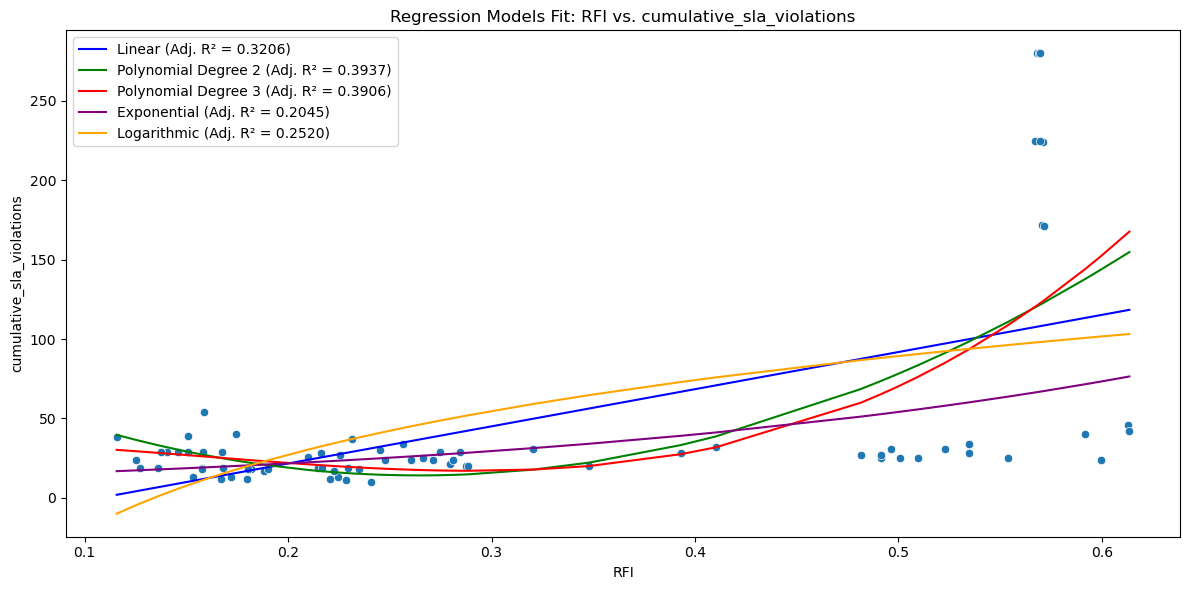

In [11]:
# Carregar o dataset
df = dt_metric  # ou substitua por seu DataFrame já carregado

# Definir variáveis genéricas
x_var = "RFI"
y_var = "cumulative_sla_violations"
#hue_var = dt_rfi_sla_delay_power_drop['algorithm']
hue_var = None
X = df[x_var].values.reshape(-1, 1)
y = df[y_var].values

# Função para calcular R² ajustado
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Modelos de regressão
models = {}

# Linear
lin_reg = LinearRegression().fit(X, y)
y_lin = lin_reg.predict(X)
models["Linear"] = (y_lin, adjusted_r2(r2_score(y, y_lin), len(y), 1))

# Polinomial grau 2
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)
poly2_reg = LinearRegression().fit(X_poly2, y)
y_poly2 = poly2_reg.predict(X_poly2)
models["Polynomial Degree 2"] = (y_poly2, adjusted_r2(r2_score(y, y_poly2), len(y), 2))

# Polinomial grau 3
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)
poly3_reg = LinearRegression().fit(X_poly3, y)
y_poly3 = poly3_reg.predict(X_poly3)
models["Polynomial Degree 3"] = (y_poly3, adjusted_r2(r2_score(y, y_poly3), len(y), 3))

# Exponencial
log_y = np.log(y + 1e-9)
exp_reg = LinearRegression().fit(X, log_y)
y_exp = np.exp(exp_reg.predict(X))
models["Exponential"] = (y_exp, adjusted_r2(r2_score(y, y_exp), len(y), 2))

# Logarítmico
X_log = np.log(X + 1e-9)
log_reg = LinearRegression().fit(X_log, y)
y_log = log_reg.predict(X_log)
models["Logarithmic"] = (y_log, adjusted_r2(r2_score(y, y_log), len(y), 2))

# Plot com seaborn
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df[x_var], y=df[y_var], hue=hue_var)

colors = {
    "Linear": "blue",
    "Polynomial Degree 2": "green",
    "Polynomial Degree 3": "red",
    "Exponential": "purple",
    "Logarithmic": "orange"
}

for name, (y_pred, adj_r2) in models.items():
    sns.lineplot(x=df[x_var], y=y_pred, label=f"{name} (Adj. R² = {adj_r2:.4f})", color=colors[name])

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Regression Models Fit: {x_var} vs. {y_var}")
plt.legend()
plt.tight_layout()
#plt.savefig(f"{x_var}_vs_{y_var}_all_models.png")
plt.show()


In [12]:
# Carregar o dataset
df = dt_metric

# Selecionar colunas relevantes para clustering
features = ["cumulative_sla_violations", "Delays", "Power Consumption", "RFI"]
#features = ["cumulative_sla_violations", "RFI"]
X = df[features].dropna()

# Normalizar os dados
X_first_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)

## Definindo a quantidade de componentes
n = len(features)
## Objeto contendo as informações do modelo
rules = PCA(n_components=n)
## Criando o nome das colunas
cols = []
for i in range(1, (rules.n_components + 1)):
    cols.append('PC' + str(i))
    
## Reduzindo dimensionalidade com PCA
pca_dt = pd.DataFrame(rules.fit_transform(X_first_scaled).round(4), columns=cols, index=X_first_scaled.index)

## Coeficientes de cada componente do modelo
pca_coef = pd.DataFrame(rules.components_.T, columns=cols, index=X_first_scaled.columns)
## Variância explicada pelo modelo
### Transformando em dataframe
pca_explicada = pd.DataFrame(rules.explained_variance_ratio_*100).reset_index()
### Renomeando
pca_explicada.columns = ['PC', 'Explicada_%']
### Corrigindo valor para componentes
pca_explicada['PC'] = range(1, (rules.n_components + 1))
### Adicionando variável para armazenar variância acumulada
pca_explicada['Cum_Explicada_%'] = pca_explicada['Explicada_%'].cumsum()
display(pca_explicada.head(2))
display(pca_coef[['PC1', 'PC2']])

,PC,Explicada_%,Cum_Explicada_%
0,1,46.084760,46.084760
1,2,24.295553,70.380313


c:\Users\lucasa88\.conda\envs\smartplan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lucasa88\.conda\envs\smartplan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lucasa88\.conda\envs\smartplan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lucasa88\.conda\envs\smartplan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

elbow k 2 inertia 211.8476642371656
elbow k 3 inertia 135.23697503088175
elbow k 4 inertia 85.95051804946505
elbow k 5 inertia 45.073343804778304
elbow k 6 inertia 36.46052756931333
elbow k 7 inertia 19.23937613668569
elbow k 8 inertia 13.12794280684364
elbow k 9 inertia 10.931296404934306
elbow k 10 inertia 8.396714008614062


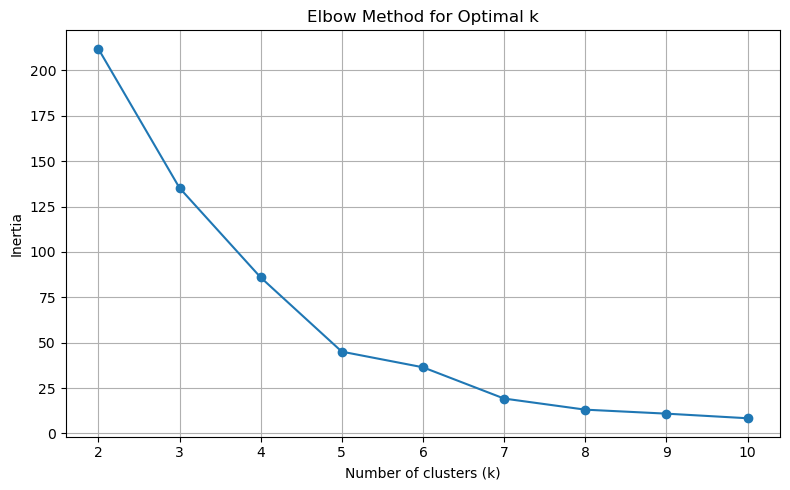

c:\Users\lucasa88\.conda\envs\smartplan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lucasa88\.conda\envs\smartplan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lucasa88\.conda\envs\smartplan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lucasa88\.conda\envs\smartplan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

silhouette k 2 score 0.46852849939073166
silhouette k 3 score 0.47045630130893434
silhouette k 4 score 0.5067684005089468
silhouette k 5 score 0.6086098115083654
silhouette k 6 score 0.6209707753258763
silhouette k 7 score 0.6908653633012233
silhouette k 8 score 0.7003722055513093
silhouette k 9 score 0.6550750678023984
silhouette k 10 score 0.6887141721651067


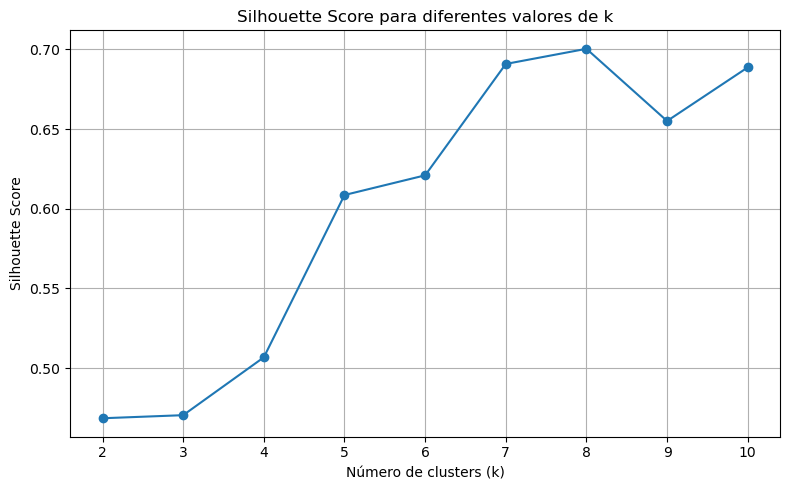

In [15]:
#x_kmeans = pca_dt.loc[:, ['PC1', 'PC2']]
random_number = seed_list[6]
x_kmeans = X_first_scaled

# Elbow method to determine optimal number of clusters
inertia = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=random_number)
    kmeans.fit(x_kmeans)
    inertia.append(kmeans.inertia_)
    print('elbow k', k, 'inertia', kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcular Silhouette Score para diferentes valores de k
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=random_number)
    labels = kmeans.fit_predict(x_kmeans)
    score = silhouette_score(x_kmeans, labels)
    silhouette_scores.append(score)
    print('silhouette k', k, 'score', score)

# Plotar o gráfico
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score para diferentes valores de k')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\lucasa88\.conda\envs\smartplan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


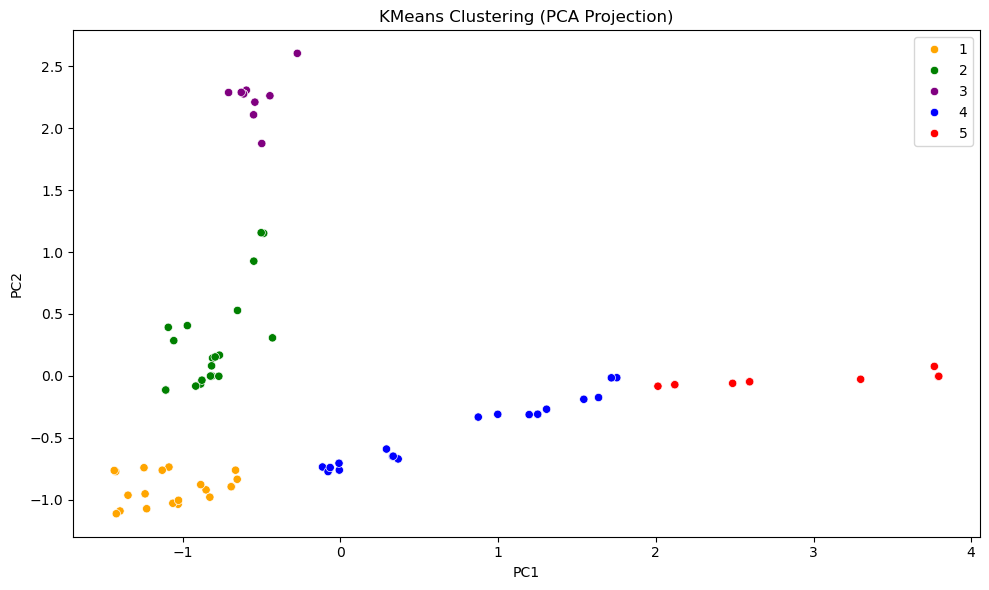

Número de elementos por cluster:
cluster
4    20
2    20
1    20
5    10
3    10
Name: count, dtype: int64


In [16]:
# Aplicar KMeans
kmeans = KMeans(n_clusters=5, random_state=random_number)
clusters = kmeans.fit_predict(x_kmeans)

# manipulations to convert from the original cluster output to final paper plot
clusters[clusters == 4] = 10
clusters[clusters == 2] = 20
clusters[clusters == 1] = 30
clusters[clusters == 0] = 40
clusters[clusters == 3] = 50

clusters = (clusters/10).astype(int)

dt_rfi_sla_delay_power_drop['cluster'] = clusters
pca_dt['cluster'] = clusters

# Plotar os clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_dt.iloc[:, 0], y=pca_dt.iloc[:, 1], hue=clusters, palette=['orange', 'green', 'purple', 'blue', 'red'])
plt.title("KMeans Clustering (PCA Projection)")
plt.tight_layout()
plt.savefig("kmeans_clusters_pca_to_paper.png")
plt.show()


# Exibir número de elementos por cluster
print("Número de elementos por cluster:")
print(dt_rfi_sla_delay_power_drop["cluster"].value_counts())
dt_rfi_sla_delay_power_drop["cluster"] = dt_rfi_sla_delay_power_drop["cluster"].astype(str)
dt_rfi_sla_delay_power_drop["algo_load_cloud"] = dt_rfi_sla_delay_power_drop["algorithm"] + "_" + dt_rfi_sla_delay_power_drop["workload"] + "_" + dt_rfi_sla_delay_power_drop["cloud"]
# coordinates values to plot on overleaf
pca_dt.loc[:, ['PC1', 'PC2', 'cluster']].to_csv('list_of_coordinates.csv', index=False)

In [17]:
dt_rfi_sla_delay_power_drop.groupby(by='cluster')[features].agg(['count', 'mean', 'std', 'min', 'max']).T

cluster                                   1           2           3  \
cumulative_sla_violations count   20.000000   20.000000   10.000000   
                          mean    20.550000   28.600000   27.300000   
                          std      6.870800    9.708379    3.917199   
                          min     10.000000   13.000000   20.000000   
                          max     34.000000   54.000000   32.000000   
Delays                    count   20.000000   20.000000   10.000000   
                          mean    29.113455   84.912891  153.161724   
                          std      6.372602   15.212632    7.458824   
                          min     22.777778   71.052632  145.161290   
                          max     40.000000  117.666667  171.785714   
Power Consumption         count   20.000000   20.000000   10.000000   
                          mean   170.336872  193.072858  181.330836   
                          std      3.379745    5.414619   11.004250   
                          min    165.417934  183.672543  172.927087   
                          max    175.535421  200.740327  200.069258   
RFI                       count   20.000000   20.000000   10.000000   
                          mean     0.217384    0.163061    0.448342   
                          std      0.044037    0.036768    0.073720   
                          min      0.125109    0.115760    0.320519   
                          max      0.284615    0.247603    0.522751   

cluster                                   4           5  
cumulative_sla_violations count   20.000000   10.000000  
                          mean    25.850000  225.200000  
                          std      9.382374   44.369158  
                          min     12.000000  171.000000  
                          max     46.000000  280.000000  
Delays                    count   20.000000   10.000000  
                          mean    28.042539   29.696003  
                          std      3.597251    1.296570  
                          min     22.500000   27.857143  
                          max     32.758621   31.714286  
Power Consumption         count   20.000000   10.000000  
                          mean   205.865691  197.532087  
                          std      2.385932   12.396884  
                          min    200.870087  185.543864  
                          max    208.902660  212.079439  
RFI                       count   20.000000   10.000000  
                          mean     0.400930    0.569877  
                          std      0.162762    0.001460  
                          min      0.214865    0.567163  
                          max      0.613469    0.571479

In [18]:
display(dt_rfi_sla_delay_power_drop.groupby(by='cluster')[['cumulative_sla_violations', 'Delays', 'Power Consumption', 'drop', 'RFI']].corr()[['RFI']].reset_index())
display(dt_rfi_sla_delay_power_drop.groupby(by='cluster')[['cumulative_sla_violations', 'Delays', 'Power Consumption', 'drop', 'RFI']].corr(method='spearman')[['RFI']].reset_index())

,cluster,level_1,RFI
0,1,cumulative_sla_violations,0.458587
1,1,Delays,-0.461518
2,1,Power Consumption,0.382816
3,1,drop,NaN
4,1,RFI,1.000000
5,2,cumulative_sla_violations,0.078044
6,2,Delays,0.834914
7,2,Power Consumption,0.505573
8,2,drop,NaN
9,2,RFI,1.000000


,cluster,level_1,RFI
0,1,cumulative_sla_violations,0.449327
1,1,Delays,-0.411012
2,1,Power Consumption,0.406934
3,1,drop,NaN
4,1,RFI,1.000000
5,2,cumulative_sla_violations,0.165560
6,2,Delays,0.631589
7,2,Power Consumption,0.605752
8,2,drop,NaN
9,2,RFI,1.000000


In [19]:
dt_rfi_sla_delay_power_drop.groupby(by='cluster')['algo_load_cloud'].value_counts()

cluster  algo_load_cloud
1        tetris_low_off     10
         tetris_low_on      10
2        tetris_high_on     10
         thea_low_on        10
3        thea_high_on       10
4        tetris_high_off    10
         thea_low_off       10
5        thea_high_off      10
Name: count, dtype: int64

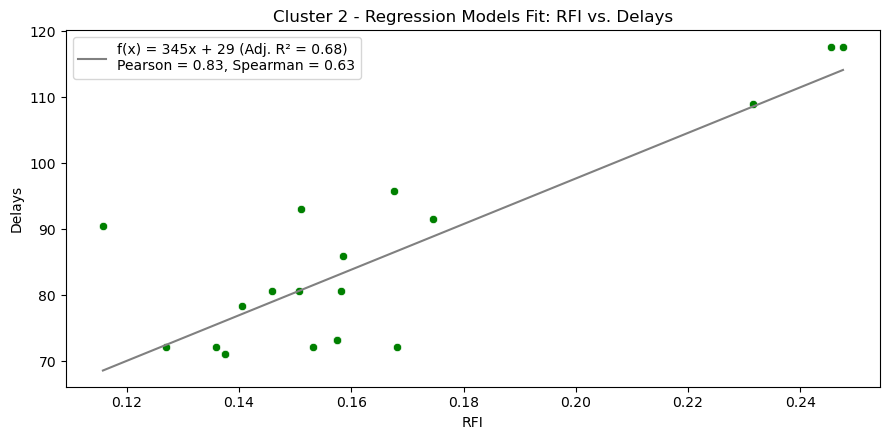

In [46]:
# Filtrar o DataFrame para o cluster 2
df = dt_rfi_sla_delay_power_drop.loc[dt_rfi_sla_delay_power_drop['cluster'] == '2']

# Definir variáveis
x_var = "RFI"
y_var = "Delays"
X = df[x_var].values.reshape(-1, 1)
y = df[y_var].values

# Função para calcular R² ajustado
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Regressão linear
lin_reg = LinearRegression().fit(X, y)
y_lin = lin_reg.predict(X)
adj_r2 = adjusted_r2(r2_score(y, y_lin), len(y), 1)

# Coeficientes da equação
a = lin_reg.coef_[0]
b = lin_reg.intercept_
equation_text = f"f(x) = {a:.0f}x + {b:.0f}"

# Plot
plt.figure(figsize=(9, 4.5))
sns.scatterplot(x=df[x_var], y=df[y_var], color='green')
sns.lineplot(x=df[x_var], y=y_lin, label=f"{equation_text} (Adj. R² = {adj_r2:.2f})\nPearson = 0.83, Spearman = 0.63", color='gray')

# save to send to overleaf
df[[x_var, y_var]].reset_index(drop=True).to_csv(f"cluster2_{x_var}_vs_{y_var}_data.csv", index=False)

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Cluster 2 - Regression Models Fit: {x_var} vs. {y_var}")
plt.legend()
plt.tight_layout()
plt.savefig(f"cluster2_{x_var}_vs_{y_var}_linear_model_with_equation.png")
plt.show()

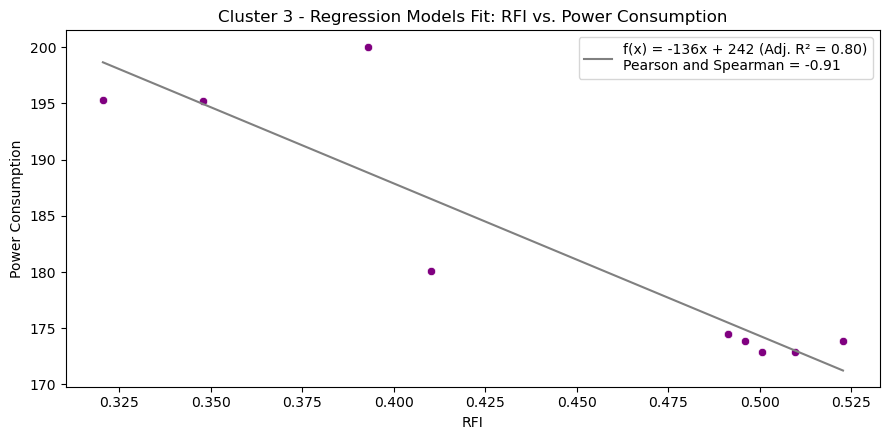

In [45]:
# Filtrar o DataFrame para o cluster 3
df = dt_rfi_sla_delay_power_drop.loc[dt_rfi_sla_delay_power_drop['cluster'] == '3']

# Definir variáveis
x_var = "RFI"
y_var = "Power Consumption"
X = df[x_var].values.reshape(-1, 1)
y = df[y_var].values

# Função para calcular R² ajustado
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Regressão linear
lin_reg = LinearRegression().fit(X, y)
y_lin = lin_reg.predict(X)
adj_r2 = adjusted_r2(r2_score(y, y_lin), len(y), 1)

# Coeficientes da equação
a = lin_reg.coef_[0]
b = lin_reg.intercept_
equation_text = f"f(x) = {a:.0f}x + {b:.0f}"

# Plot
plt.figure(figsize=(9, 4.5))
sns.scatterplot(x=df[x_var], y=df[y_var], color='purple')
sns.lineplot(x=df[x_var], y=y_lin, label=f"{equation_text} (Adj. R² = {adj_r2:.2f})\nPearson and Spearman = -0.91", color='gray')

# save to send to overleaf
df[[x_var, y_var]].reset_index(drop=True).to_csv(f"cluster3_{x_var}_vs_{y_var}_data.csv", index=False)

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Cluster 3 - Regression Models Fit: {x_var} vs. {y_var}")
plt.legend()
plt.tight_layout()
plt.savefig(f"cluster3_{x_var}_vs_{y_var}_linear_model_with_equation.png")
plt.show()

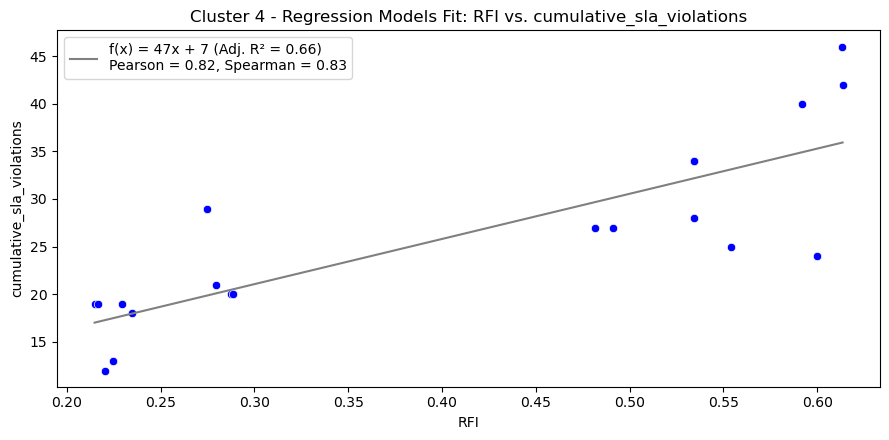

In [44]:
# Filtrar o DataFrame para o cluster 3
df = dt_rfi_sla_delay_power_drop.loc[dt_rfi_sla_delay_power_drop['cluster'] == '4']

# Definir variáveis
x_var = "RFI"
y_var = "cumulative_sla_violations"
X = df[x_var].values.reshape(-1, 1)
y = df[y_var].values

# Função para calcular R² ajustado
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Regressão linear
lin_reg = LinearRegression().fit(X, y)
y_lin = lin_reg.predict(X)
adj_r2 = adjusted_r2(r2_score(y, y_lin), len(y), 1)

# Coeficientes da equação
a = lin_reg.coef_[0]
b = lin_reg.intercept_
equation_text = f"f(x) = {a:.0f}x + {b:.0f}"

# Plot
plt.figure(figsize=(9, 4.5))
sns.scatterplot(x=df[x_var], y=df[y_var], color='blue')
sns.lineplot(x=df[x_var], y=y_lin, label=f"{equation_text} (Adj. R² = {adj_r2:.2f})\nPearson = 0.82, Spearman = 0.83", color='gray')

# save to send to overleaf
df[[x_var, y_var]].reset_index(drop=True).to_csv(f"cluster4_{x_var}_vs_{y_var}_data.csv", index=False)

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Cluster 4 - Regression Models Fit: {x_var} vs. {y_var}")
plt.legend()
plt.tight_layout()
plt.savefig(f"cluster4_{x_var}_vs_{y_var}_linear_model_with_equation.png")
plt.show()

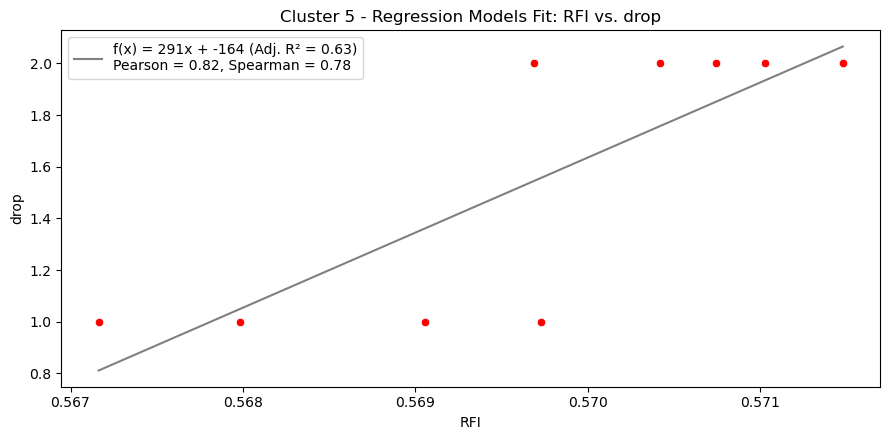

In [43]:
# Filtrar o DataFrame para o cluster 3
df = dt_rfi_sla_delay_power_drop.loc[dt_rfi_sla_delay_power_drop['cluster'] == '5']

# Definir variáveis
x_var = "RFI"
y_var = "drop"
X = df[x_var].values.reshape(-1, 1)
y = df[y_var].values

# Função para calcular R² ajustado
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Regressão linear
lin_reg = LinearRegression().fit(X, y)
y_lin = lin_reg.predict(X)
adj_r2 = adjusted_r2(r2_score(y, y_lin), len(y), 1)

# Coeficientes da equação
a = lin_reg.coef_[0]
b = lin_reg.intercept_
equation_text = f"f(x) = {a:.0f}x + {b:.0f}"

# Plot
plt.figure(figsize=(9, 4.5))
sns.scatterplot(x=df[x_var], y=df[y_var], color='red')
sns.lineplot(x=df[x_var], y=y_lin, label=f"{equation_text} (Adj. R² = {adj_r2:.2f})\nPearson = 0.82, Spearman = 0.78", color='gray')

# save to send to overleaf
df[[x_var, y_var]].reset_index(drop=True).to_csv(f"cluster5_{x_var}_vs_{y_var}_data.csv", index=False)

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Cluster 5 - Regression Models Fit: {x_var} vs. {y_var}")
plt.legend()
plt.tight_layout()
plt.savefig(f"cluster5_{x_var}_vs_{y_var}_linear_model_with_equation.png")
plt.show()

,RFI,drop
40,0.567983,1
41,0.567163,1
42,0.571479,2
43,0.570745,2
44,0.570422,2
45,0.569054,1
46,0.569729,1
47,0.571479,2
48,0.571026,2
49,0.569688,2
